# Gene Ontology Analysis
# Phase 2 vs. Phase 2
using output from [deseq_p2.v.p2.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_p2.v.p2.ipynb), specifically in general/stressor specific gene groups identified with [upset plots](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/new_refGenome/upset_p2.v.p2.ipynb)

following workflow described [here](https://robertslab.github.io/resources/bio-Annotation/) from the Roberts Lab

## 0. load libraries

In [32]:
# for gene ontology
library(GSEABase)
library(GO.db)

# for data formatting
library(tidyverse)

# for color palette
library(RColorBrewer)

# for combining plots
library(patchwork)

# for upset plot
library(UpSetR)

## 1. Map GO IDs to gene IDs

In [3]:
# read in gene ID to GO file
gene2go <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ref_files/annotations/newRef_geneGO.csv')
head(gene2go)

,gene,Gene.Ontology.IDs
,<chr>,<chr>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655
2,LOC111099032,GO:0004930;GO:0005886;GO:0007186
3,LOC111099037,GO:0000978;GO:0000981;GO:0006355
4,LOC111099039,GO:0004930;GO:0005886;GO:0007189
5,LOC111099040,GO:0005515;GO:0007169;GO:0035556
6,LOC111099041,GO:0016020;GO:0022857;GO:0055085


## 2. Create `gene2goSlim` function
to reduce code redundancy

**code is taken directly from Roberts Lab Annotation Handbook** - see [here](https://robertslab.github.io/resources/bio-Annotation/#map-go-ids-to-goslims)
- but this is slightly modified to allow the user to input which GO processes they want to get returned (BP, MF, or CC)

see bottom of code notebook for outputs of various parts of this function

In [4]:
gene2goSlim <- function(gene2go, deg_df, ontology = "BP") {

    gene_go <- left_join(deg_df, gene2go, by = "gene")

colnames(gene_go) <- c('gene_id', 'Gene.Ontology.IDs')
    
# Column names corresponding to gene name/ID and GO IDs
GO.ID.column <- "Gene.Ontology.IDs"
gene.ID.column <- "gene_id"

# Relative path or URL to input file
### BOTH vs. CONTROL
input.file <- gene_go

##### Official GO info - no need to change #####
goslims_obo <- "goslim_generic.obo"
goslims_url <- "http://current.geneontology.org/ontology/subsets/goslim_generic.obo"

# Find GSEAbase installation location
gseabase_location <- find.package("GSEABase")

# Load path to GOslim OBO file
goslim_obo_destintation <- file.path(gseabase_location, "extdata", goslims_obo, fsep = "/")

# Download the GOslim OBO file
download.file(url = goslims_url, destfile = goslim_obo_destintation)

# Loads package files
gseabase_files <- system.file("extdata", goslims_obo, package="GSEABase")

# read in gene file
#full.gene.df <- read.csv(file = input.file, header = TRUE, sep = ",")
full.gene.df <- gene_go

# Clean whitespace, filter NA/empty rows, select columns, and split GO terms using column name variables
gene.GO.df <- full.gene.df %>%
  mutate(!!GO.ID.column := str_replace_all(.data[[GO.ID.column]], "\\s*;\\s*", ";")) %>% # Clean up spaces around ";"
  filter(!is.na(.data[[gene.ID.column]]) & !is.na(.data[[GO.ID.column]]) & .data[[GO.ID.column]] != "") %>% 
  select(all_of(c(gene.ID.column, GO.ID.column)))

# flatten file
flat.gene.GO.df <- gene.GO.df %>% separate_rows(!!sym(GO.ID.column), sep = ";")

# group genes by GO.ID
grouped.gene.GO.df <- flat.gene.GO.df %>%
  group_by(!!sym(GO.ID.column)) %>%
  summarise(!!gene.ID.column := paste(.data[[gene.ID.column]], collapse = ","))

# Vector of GO IDs
go_ids <- grouped.gene.GO.df[[GO.ID.column]]

# create new OBO collection object of just GOslims, based on provided GO IDs
# Create GSEAbase GOCollection using `go_ids`
myCollection <- GOCollection(go_ids)

# Retrieve GOslims from GO OBO file set
slim <- getOBOCollection(gseabase_files)

# Retrieve Biological Process (BP) GOslims
slimdf <- goSlim(myCollection, slim, ontology, verbose = verbose)

# construct the offspring name dynamically
offspring_name <- switch(ontology,
                         BP = 'GOBPOFFSPRING',
                         MF = 'GOMFOFFSPRING',
                         CC = 'GOCCOFFSPRING')

# retrieve correct offspring object
offspring_obj <- get(offspring_name)
    
# List of GOslims and all GO IDs from `go_ids`
gomap <- as.list(offspring_obj[rownames(slimdf)])

# Maps `go_ids` to matching GOslims
mapped <- lapply(gomap, intersect, ids(myCollection))

# Append all mapped GO IDs to `slimdf`
# `sapply` needed to apply paste() to create semi-colon delimited values
slimdf$GO.IDs <- sapply(lapply(gomap, intersect, ids(myCollection)), paste, collapse=";")

# Remove "character(0) string from "GO.IDs" column
slimdf$GO.IDs[slimdf$GO.IDs == "character(0)"] <- ""

# Add self-matching GOIDs to "GO.IDs" column, if not present
for (go_id in go_ids) {
  # Check if the go_id is present in the row names
  if (go_id %in% rownames(slimdf)) {
    # Check if the go_id is not present in the GO.IDs column
    # Also removes white space "trimws()" and converts all to upper case to handle
    # any weird, "invisible" formatting issues.
    if (!go_id %in% trimws(toupper(strsplit(slimdf[go_id, "GO.IDs"], ";")[[1]]))) {
      # Append the go_id to the GO.IDs column with a semi-colon separator
      if (length(slimdf$GO.IDs) > 0 && nchar(slimdf$GO.IDs[nrow(slimdf)]) > 0) {
        slimdf[go_id, "GO.IDs"] <- paste0(slimdf[go_id, "GO.IDs"], "; ", go_id)
      } else {
        slimdf[go_id, "GO.IDs"] <- go_id
      }
    }
  }
}

# "Flatten" file so each row is single GO ID with corresponding GOslim
# rownames_to_column needed to retain row name info
slimdf_separated <- as.data.frame(slimdf %>%
  rownames_to_column('GOslim') %>%
  separate_rows(GO.IDs, sep = ";"))

# Group by unique GO ID
grouped_slimdf <- slimdf_separated %>%
  filter(!is.na(GO.IDs) & GO.IDs != "") %>%
  group_by(GO.IDs) %>%
  summarize(GOslim = paste(GOslim, collapse = ";"),
            Term = paste(Term, collapse = ";"))

slimdf.sorted <- slimdf %>% arrange(desc(Count))

slim.count.df <- slimdf.sorted %>% 
  select(Term, Count)

return(slim.count.df)

    }

## Early Life Stress
SC vs. CC (where S is any stressor: H, W, or B)

### DEGs shared in all three comparisons

In [7]:
# read in DEG file
earlyLife_shared <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deg_interest/earlyLife_sharedAll.csv') %>%
select(gene)

head(earlyLife_shared)

,gene
,<chr>
1,LOC111102028
2,LOC111127247
3,LOC144622232
4,LOC144624450
5,LOC144623104
6,LOC111116266


In [8]:
# biological processes
earlyLifeShare_goSlim.BP <- gene2goSlim(gene2go,earlyLife_shared, "BP")
head(earlyLifeShare_goSlim.BP, 2)

# molecular function
earlyLifeShare_goSlim.MF <- gene2goSlim(gene2go,earlyLife_shared, "MF")
head(earlyLifeShare_goSlim.MF, 2)

# biological processes
earlyLifeShare_goSlim.CC <- gene2goSlim(gene2go,earlyLife_shared, "CC")
head(earlyLifeShare_goSlim.CC, 2)

,Term,Count
,<chr>,<int>
GO:0030163,protein catabolic process,1
GO:0055085,transmembrane transport,1


,Term,Count
,<chr>,<int>
GO:0003824,catalytic activity,3
GO:0005215,transporter activity,1


,Term,Count
,<chr>,<int>
GO:0005576,extracellular region,2
GO:0030312,external encapsulating structure,1


In [16]:
earlyLifeShare.BP.top20 <- earlyLifeShare_goSlim.BP %>%
  arrange(desc(Count)) %>% # order from most to least
slice_head(n = 20) %>% # take top 20 rows 
mutate(GO_cat = 'Biological Process')

earlyLifeShare.MF.top20 <- earlyLifeShare_goSlim.MF %>%
  arrange(desc(Count)) %>% # order from most to least
slice_head(n = 20) %>%        # take top 20 rows
mutate(GO_cat = 'Moleucular Function')

earlyLifeShare.CC.top20 <- earlyLifeShare_goSlim.CC %>%
  arrange(desc(Count)) %>% # order from most to least
slice_head(n = 20) %>%        # take top 20 rows
mutate(GO_cat = 'Cellular Component')

In [19]:
earlyLifeShared.df <- rbind(earlyLifeShare.BP.top20, earlyLifeShare.MF.top20, earlyLifeShare.CC.top20) %>%
filter(Count != 0)

head(earlyLifeShared.df)

,Term,Count,GO_cat
,<chr>,<int>,<chr>
GO:0030163,protein catabolic process,1,Biological Process
GO:0055085,transmembrane transport,1,Biological Process
GO:0003824,catalytic activity,3,Moleucular Function
GO:0005215,transporter activity,1,Moleucular Function
GO:0016491,oxidoreductase activity,1,Moleucular Function
GO:0016740,transferase activity,1,Moleucular Function


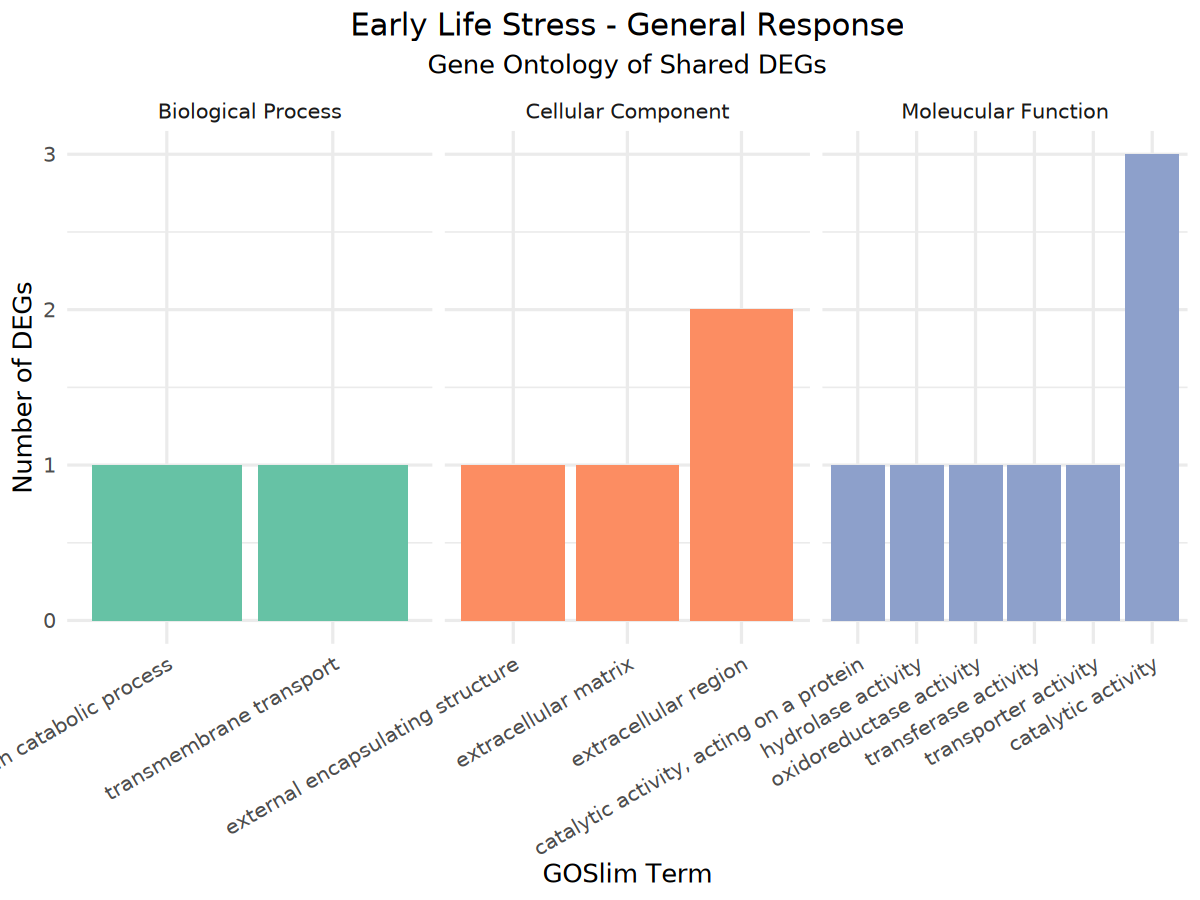

In [42]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

ggplot(earlyLifeShared.df, aes(x = reorder(Term, Count), y = Count, fill = GO_cat)) +
geom_col() +
facet_wrap(~GO_cat, scales = 'free_x', space = 'fixed') +
scale_fill_brewer(palette = 'Set2') +
labs(x = 'GOSlim Term',
     y = 'Number of DEGs',
     title = 'Early Life Stress - General Response',
    subtitle = 'Gene Ontology of Shared DEGs') +
theme_minimal(base_size = 15) + 
theme(axis.text.x = element_text(angle = 30, vjust = 1, hjust = 1),
     legend.position = 'none',
     plot.title = element_text(hjust = 0.5),
      plot.subtitle = element_text(hjust = 0.5))

## Stressor Sets
SC vs. CC
CS vs. CC
SS vs. CC
(where S is the same stressor for all the sets; H, W, or B)

### DEGs shared in all three comparisons

In [43]:
# read in DEG file
warm_shared <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deg_interest/warm_sharedAll.csv') %>%
select(gene)

head(warm_shared)

,gene
,<chr>
1,LOC111102028
2,LOC111127247
3,LOC144624450
4,LOC144623813
5,LOC144623104
6,LOC111113307


In [44]:
# biological processes
warm_shared_goSlim.BP <- gene2goSlim(gene2go,warm_shared, "BP")
head(warm_shared_goSlim.BP, 2)

# molecular function
warm_shared_goSlim.MF <- gene2goSlim(gene2go,warm_shared, "MF")
head(warm_shared_goSlim.MF, 2)

# biological processes
warm_shared_goSlim.CC <- gene2goSlim(gene2go,warm_shared, "CC")
head(warm_shared_goSlim.CC, 2)

,Term,Count
,<chr>,<int>
GO:0000278,mitotic cell cycle,0
GO:0000910,cytokinesis,0


,Term,Count
,<chr>,<int>
GO:0003824,catalytic activity,3
GO:0016787,hydrolase activity,2


,Term,Count
,<chr>,<int>
GO:0005576,extracellular region,2
GO:0030312,external encapsulating structure,1


In [45]:
warm_shared.BP.top20 <- warm_shared_goSlim.BP %>%
  arrange(desc(Count)) %>% # order from most to least
slice_head(n = 20) %>% # take top 20 rows 
mutate(GO_cat = 'Biological Process')

warm_shared.MF.top20 <- warm_shared_goSlim.MF %>%
  arrange(desc(Count)) %>% # order from most to least
slice_head(n = 20) %>%        # take top 20 rows
mutate(GO_cat = 'Moleucular Function')

warm_shared.CC.top20 <- warm_shared_goSlim.CC %>%
  arrange(desc(Count)) %>% # order from most to least
slice_head(n = 20) %>%        # take top 20 rows
mutate(GO_cat = 'Cellular Component')

In [46]:
warm_shared.df <- rbind(warm_shared.BP.top20, warm_shared.MF.top20, warm_shared.CC.top20) %>%
filter(Count != 0)

head(warm_shared.df)

,Term,Count,GO_cat
,<chr>,<int>,<chr>
GO:0003824,catalytic activity,3,Moleucular Function
GO:0016787,hydrolase activity,2,Moleucular Function
GO:0140096,"catalytic activity, acting on a protein",2,Moleucular Function
GO:0016740,transferase activity,1,Moleucular Function
GO:0005576,extracellular region,2,Cellular Component
GO:0030312,external encapsulating structure,1,Cellular Component


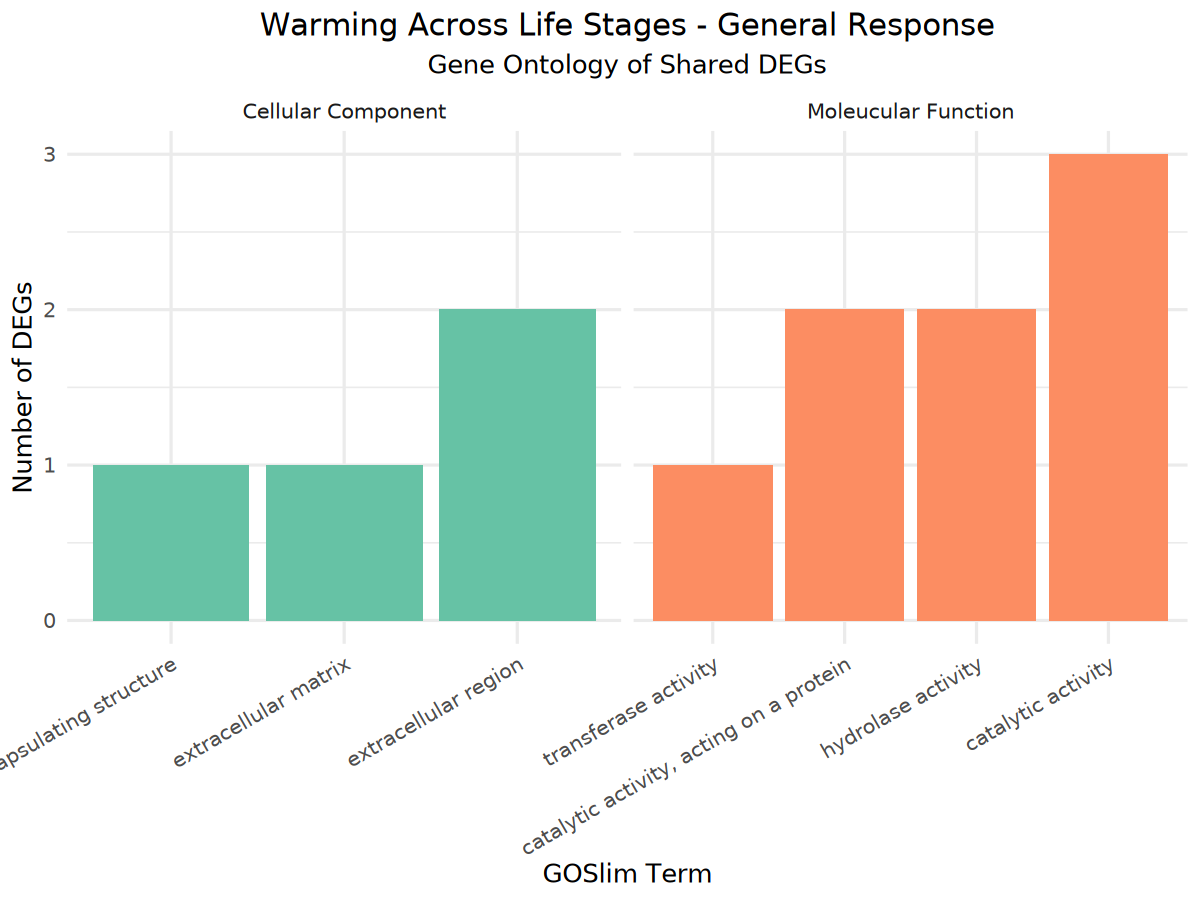

In [50]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

ggplot(warm_shared.df, aes(x = reorder(Term, Count), y = Count, fill = GO_cat)) +
geom_col() +
facet_wrap(~GO_cat, scales = 'free_x', space = 'fixed') +
scale_fill_brewer(palette = 'Set2') +
labs(x = 'GOSlim Term',
     y = 'Number of DEGs',
     title = 'Warming Across Life Stages - General Response',
    subtitle = 'Gene Ontology of Shared DEGs') +
theme_minimal(base_size = 15) + 
theme(axis.text.x = element_text(angle = 30, vjust = 1, hjust = 1),
     legend.position = 'none',
     plot.title = element_text(hjust = 0.5),
      plot.subtitle = element_text(hjust = 0.5))